In [2]:
import pandas as pd
df = pd.read_csv("ClimateTest.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          114 non-null    datetime64[ns]
 1   meantemp      114 non-null    float64       
 2   humidity      114 non-null    float64       
 3   wind_speed    114 non-null    float64       
 4   meanpressure  114 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 4.6 KB


In [6]:
from sklearn.preprocessing import MinMaxScaler

df = df.sort_values('date')
df = df.set_index('date')
train_values = df["meantemp"].values.reshape(-1, 1)
test_values = df["meantemp"].values.reshape(-1, 1)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_values)
test_scaled = scaler.transform(test_values)

In [7]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
for train_index, test_index in tscv.split(df):
    train_data = df.iloc[train_index]
    test_data = df.iloc[test_index]

In [8]:
import numpy as np
def create_sequences(data, window=10):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)
X_train, y_train = create_sequences(train_scaled, window=10)
combined = np.concatenate((train_scaled[-10:], test_scaled), axis=0)
X_test, y_test = create_sequences(combined, window=10)

In [9]:
import torch
import torch.nn as nn

def to_tensor(x):
    if isinstance(x, torch.Tensor):
        return x.clone().detach().float()
    else:
        return torch.tensor(x, dtype=torch.float32)

X_train = to_tensor(X_train)
y_train = to_tensor(y_train)
X_test = to_tensor(X_test)
y_test = to_tensor(y_test)

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out
loss_fn = nn.MSELoss()
model = RNNModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.1563
Epoch 1, Loss: 0.1393
Epoch 2, Loss: 0.1238
Epoch 3, Loss: 0.1097
Epoch 4, Loss: 0.0972
Epoch 5, Loss: 0.0862
Epoch 6, Loss: 0.0768
Epoch 7, Loss: 0.0690
Epoch 8, Loss: 0.0628
Epoch 9, Loss: 0.0583
Epoch 10, Loss: 0.0555
Epoch 11, Loss: 0.0542
Epoch 12, Loss: 0.0542
Epoch 13, Loss: 0.0549
Epoch 14, Loss: 0.0559
Epoch 15, Loss: 0.0564
Epoch 16, Loss: 0.0561
Epoch 17, Loss: 0.0551
Epoch 18, Loss: 0.0533
Epoch 19, Loss: 0.0511
Epoch 20, Loss: 0.0487
Epoch 21, Loss: 0.0463
Epoch 22, Loss: 0.0442
Epoch 23, Loss: 0.0425
Epoch 24, Loss: 0.0410
Epoch 25, Loss: 0.0399
Epoch 26, Loss: 0.0389
Epoch 27, Loss: 0.0381
Epoch 28, Loss: 0.0373
Epoch 29, Loss: 0.0364


In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()

with torch.no_grad():
    y_pred = model(X_test)

y_pred = y_pred.cpu().numpy()
y_true = y_test.cpu().numpy()

y_pred = scaler.inverse_transform(y_pred)
y_true = scaler.inverse_transform(y_true)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE {mse}")
print(f"MAE {mae}")

MSE 20.269620895385742
MAE 3.8744394779205322


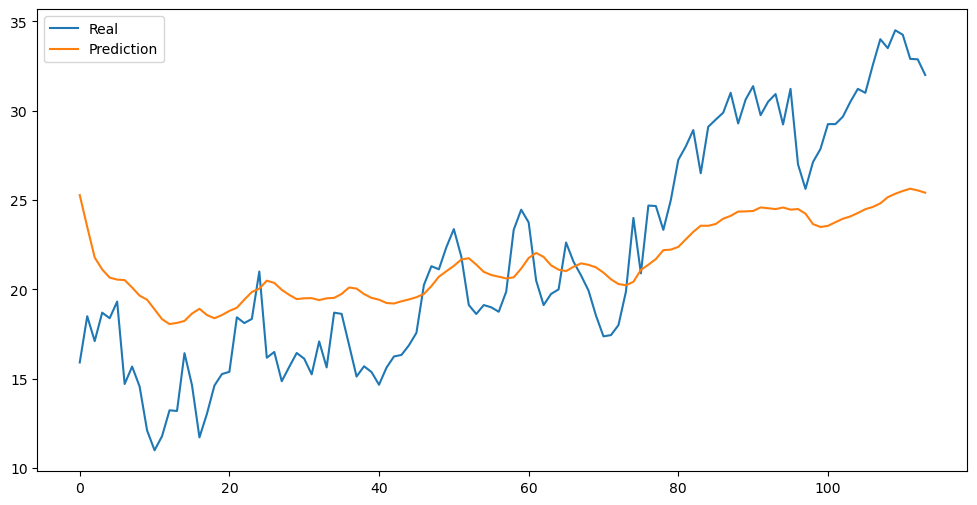

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Prediction")
plt.savefig("prediction_plot.png") 
plt.legend()
plt.show()

In [13]:
# to compare it with rnn model making a lstm model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out
loss_fn = nn.MSELoss()
model = LSTMModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.3161
Epoch 1, Loss: 0.3052
Epoch 2, Loss: 0.2947
Epoch 3, Loss: 0.2845
Epoch 4, Loss: 0.2745
Epoch 5, Loss: 0.2647
Epoch 6, Loss: 0.2552
Epoch 7, Loss: 0.2459
Epoch 8, Loss: 0.2368
Epoch 9, Loss: 0.2278
Epoch 10, Loss: 0.2189
Epoch 11, Loss: 0.2102
Epoch 12, Loss: 0.2016
Epoch 13, Loss: 0.1931
Epoch 14, Loss: 0.1848
Epoch 15, Loss: 0.1765
Epoch 16, Loss: 0.1683
Epoch 17, Loss: 0.1602
Epoch 18, Loss: 0.1522
Epoch 19, Loss: 0.1443
Epoch 20, Loss: 0.1364
Epoch 21, Loss: 0.1287
Epoch 22, Loss: 0.1211
Epoch 23, Loss: 0.1135
Epoch 24, Loss: 0.1062
Epoch 25, Loss: 0.0989
Epoch 26, Loss: 0.0919
Epoch 27, Loss: 0.0851
Epoch 28, Loss: 0.0785
Epoch 29, Loss: 0.0723


In [ ]:
model.eval()

with torch.no_grad():
    y_pred = model(X_test)

y_pred = y_pred.cpu().numpy()
y_true = y_test.cpu().numpy()

y_pred = scaler.inverse_transform(y_pred)
y_true = scaler.inverse_transform(y_true)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE {mse}")
print(f"MAE {mae}")

MSE 34.57164764404297
MAE 4.609654426574707


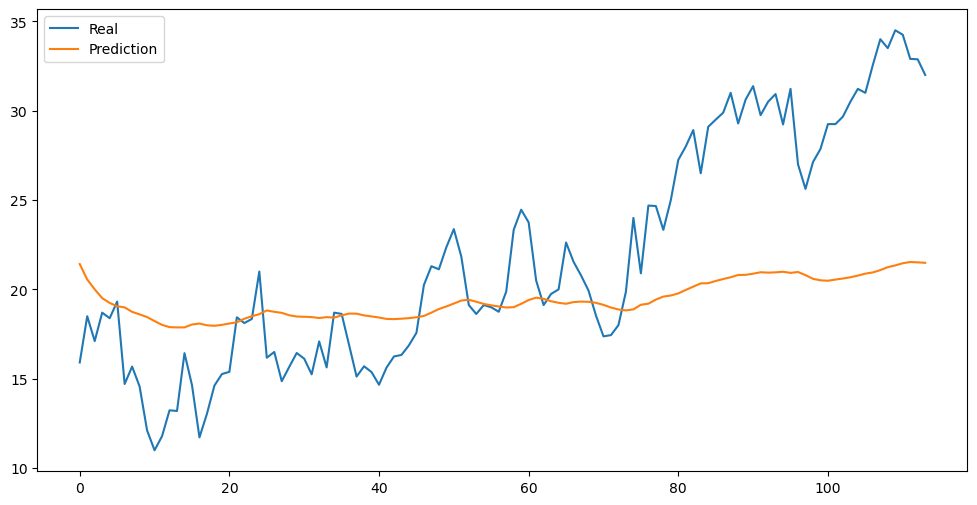

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Prediction")
plt.legend()
plt.show()

In [16]:
# had a GRU model also
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out
loss_fn = nn.MSELoss()
model = LSTMModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.1720
Epoch 1, Loss: 0.1647
Epoch 2, Loss: 0.1576
Epoch 3, Loss: 0.1507
Epoch 4, Loss: 0.1442
Epoch 5, Loss: 0.1378
Epoch 6, Loss: 0.1317
Epoch 7, Loss: 0.1258
Epoch 8, Loss: 0.1201
Epoch 9, Loss: 0.1147
Epoch 10, Loss: 0.1094
Epoch 11, Loss: 0.1043
Epoch 12, Loss: 0.0995
Epoch 13, Loss: 0.0948
Epoch 14, Loss: 0.0904
Epoch 15, Loss: 0.0862
Epoch 16, Loss: 0.0822
Epoch 17, Loss: 0.0785
Epoch 18, Loss: 0.0751
Epoch 19, Loss: 0.0720
Epoch 20, Loss: 0.0693
Epoch 21, Loss: 0.0670
Epoch 22, Loss: 0.0650
Epoch 23, Loss: 0.0635
Epoch 24, Loss: 0.0624
Epoch 25, Loss: 0.0617
Epoch 26, Loss: 0.0614
Epoch 27, Loss: 0.0613
Epoch 28, Loss: 0.0614
Epoch 29, Loss: 0.0615


In [ ]:
model.eval()

with torch.no_grad():
    y_pred = model(X_test)

y_pred = y_pred.cpu().numpy()
y_true = y_test.cpu().numpy()

y_pred = scaler.inverse_transform(y_pred)
y_true = scaler.inverse_transform(y_true)

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"MSE {mse}")
print(f"MAE {mae}")

MSE 36.39674377441406
MAE 5.401035308837891


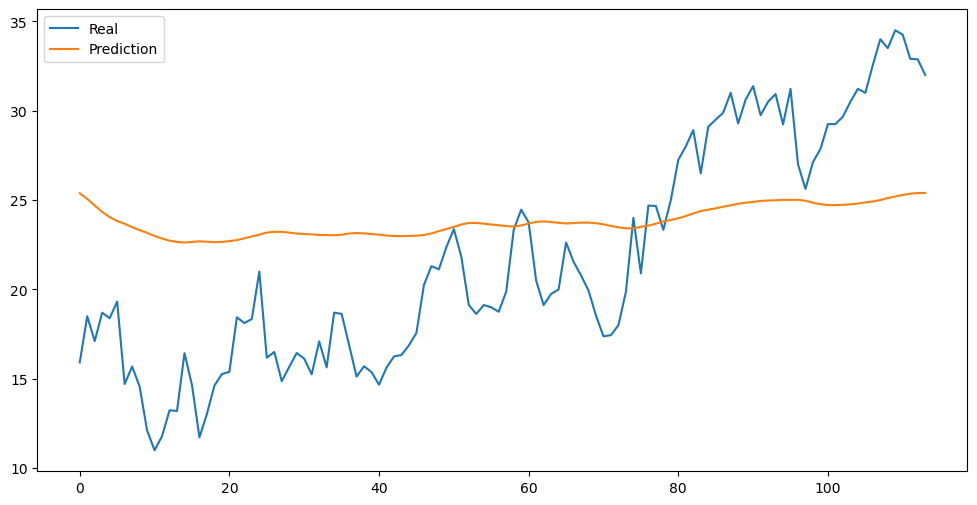

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Prediction")
plt.legend()
plt.show()